In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import acovf
from numpy.linalg import svd

# Problem 1: Housing Price Analysis Revisited

In [2]:
df = pd.read_csv("/kaggle/input/datasets/tommasofacchin/zillow-mitx-proj2/data_zillow_house_prices-proj2.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (893, 277)


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31
0,102001,0,United States,country,NaN,127881.0,128227.0,128591.0,129332.0,130079.0,...,318303.0,322658.0,327381.0,332588.0,337848.0,343392.0,348415.0,352585.0,354986.0,356026.0
1,394913,1,"New York, NY",msa,NY,224676.0,226018.0,227226.0,229604.0,231817.0,...,573600.0,576842.0,580804.0,585445.0,591876.0,599008.0,606525.0,612535.0,616856.0,619142.0
2,753899,2,"Los Angeles, CA",msa,CA,227786.0,228579.0,229794.0,232104.0,234580.0,...,845860.0,855023.0,865646.0,877802.0,895038.0,914016.0,930381.0,931707.0,928599.0,914636.0
3,394463,3,"Chicago, IL",msa,IL,170004.0,170405.0,170924.0,171963.0,173064.0,...,288807.0,291527.0,294162.0,296729.0,300023.0,303490.0,307454.0,310438.0,312286.0,312609.0
4,394514,4,"Dallas, TX",msa,TX,129921.0,130025.0,130112.0,130323.0,130544.0,...,337274.0,343129.0,350514.0,358982.0,367040.0,376487.0,385149.0,392668.0,394861.0,393920.0


## Autocovariance

rho(0) = 1442.88
rho(1) = 1403.7
rho(2) = 1363.79


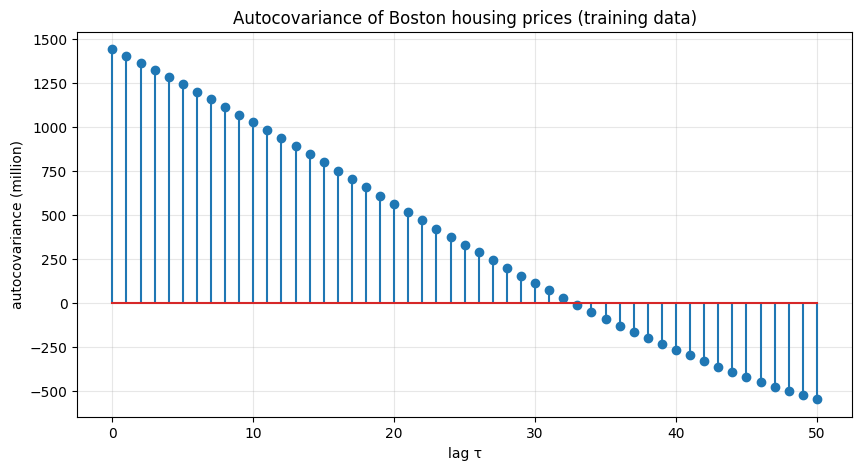

In [3]:
boston = df[df["RegionName"] == "Boston, MA"].copy()

# Keep only date columns
date_cols = [c for c in df.columns if c[:4].isdigit()]
train_cols = [c for c in date_cols if ("2010-01-31" <= c <= "2017-12-31")]

# Build training series
train = boston[train_cols].iloc[0].astype(float).values

# Autocovariance with exact convention required
rho = acovf(train, demean=True, fft=False, adjusted=False)

#  Convert to millions and round to 2 decimals
rho_million = rho / 1e6
rho0 = round(rho_million[0], 2)
rho1 = round(rho_million[1], 2)
rho2 = round(rho_million[2], 2)

print("rho(0) =", rho0)
print("rho(1) =", rho1)
print("rho(2) =", rho2)

# Plot autocovariance for lags 0 to 50
max_lag = 50
rho_lags = acovf(train, demean=True, fft=False, adjusted=False, nlag=max_lag) / 1e6
lags = np.arange(len(rho_lags))

plt.figure(figsize=(10, 5))
plt.stem(lags, rho_lags)
plt.xlabel("lag τ")
plt.ylabel("autocovariance (million)")
plt.title("Autocovariance of Boston housing prices (training data)")
plt.grid(alpha=0.3)
plt.show()

## Hankel Matrix

In [4]:
from numpy.linalg import svd

x = boston[train_cols].iloc[0].astype(float).values
L = 50                     
x = x[:L]
print("L =", len(x))

def hankel_matrix(x, m):
    L = len(x)
    n_cols = L - m + 1
    H = np.zeros((m, n_cols))
    for i in range(m):
        H[i, :] = x[i:i + n_cols]
    return H

def smallest_r_for_m(x, m, thresh=0.99):
    H = hankel_matrix(x, m)
    # SVD: H = U * diag(s) * V^T, s sorted desc
    s = svd(H, compute_uv=False)
    s2 = s**2
    total = s2.sum()
    cum = np.cumsum(s2)
    r_tilde = np.searchsorted(cum, thresh * total) + 1
    return r_tilde

for m in [5, 8, 10]:
    r_tilde = smallest_r_for_m(x, m, thresh=0.99)
    print(f"m = {m}, L = 50 -> r_tilde =", r_tilde)

L = 50
m = 5, L = 50 -> r_tilde = 1
m = 8, L = 50 -> r_tilde = 1
m = 10, L = 50 -> r_tilde = 1


## Retail Data with Multiple Time Series

In [5]:

train = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-walmart/data_walmart_train.csv")
train_missing = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-walmart/data_walmart_train_missing.csv")
test = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-walmart/data_walmart_test.csv")

for df in [train, train_missing, test]:
    df["Date"] = pd.to_datetime(df["Date"])

all_dates = pd.concat([train["Date"], test["Date"]], axis=0)
unique_sorted_dates = all_dates.sort_values().unique()
second_day = unique_sorted_dates[1]
print("Second day overall:", second_day.date())

n_weeks_train = train["Date"].nunique()
print("Number of weeks in train:", n_weeks_train)

n_weeks_test = test["Date"].nunique()
print("Number of weeks in test:", n_weeks_test)

n_cells = train_missing.size
n_missing = train_missing.isna().sum().sum()
print("Missing cells in train_missing:", n_missing, "on total", n_cells)

Second day overall: 2010-02-12
Number of weeks in train: 120
Number of weeks in test: 23
Missing cells in train_missing: 20995 on total 81240


# Problem 2: Page Matrix

In [6]:
s10_d83_full = train["s10_d83"].values
s1_d34_full  = train["s1_d34"].values

print("len s10_d83_full:", len(s10_d83_full))
print("len s1_d34_full :", len(s1_d34_full))

L = 10

def page_matrix(series, L):
    T = len(series)
    T_dash = T // L          
    s_used = series[:T_dash * L]
    P = s_used.reshape((L, T_dash), order="F")
    return P

def smallest_r_for_page(P, thresh=0.99):
    s = svd(P, compute_uv=False)
    s2 = s**2
    total = s2.sum()
    cum = np.cumsum(s2)
    r_tilde = np.searchsorted(cum, thresh * total) + 1
    return r_tilde

# r_tilde with complete data
P10_full = page_matrix(s10_d83_full, L)
P1_full  = page_matrix(s1_d34_full,  L)

r10_full = smallest_r_for_page(P10_full, thresh=0.99)
r1_full  = smallest_r_for_page(P1_full,  thresh=0.99)

print("Store s10_d83 with full data, r_tilde =", r10_full)
print("Store s1_d34 with full data,  r_tilde =", r1_full)

#  Serie with missing data: impute NaN with 0 and normalize
s10_d83_miss = train_missing["s10_d83"].values
s1_d34_miss  = train_missing["s1_d34"].values

s10_d83_miss = np.nan_to_num(s10_d83_miss, nan=0.0)
s1_d34_miss  = np.nan_to_num(s1_d34_miss,  nan=0.0)

def normalize(z):
    return (z - np.mean(z)) / np.std(z)

s10_d83_miss_norm = normalize(s10_d83_miss)
s1_d34_miss_norm  = normalize(s1_d34_miss)

P10_miss = page_matrix(s10_d83_miss_norm, L)
P1_miss  = page_matrix(s1_d34_miss_norm,  L)

r10_miss = smallest_r_for_page(P10_miss, thresh=0.99)
r1_miss  = smallest_r_for_page(P1_miss,  thresh=0.99)

print("Store s10_d83 with missing data replaced by zeros, r_tilde =", r10_miss)
print("Store s1_d34 with missing data replaced by zeros, r_tilde =", r1_miss)

len s10_d83_full: 120
len s1_d34_full : 120
Store s10_d83 with full data, r_tilde = 4
Store s1_d34 with full data,  r_tilde = 3
Store s10_d83 with missing data replaced by zeros, r_tilde = 8
Store s1_d34 with missing data replaced by zeros, r_tilde = 8


In [7]:
L = 10
r_tilde = 5

def page_matrix(series, L):
    T = len(series)
    T_dash = T // L
    s_used = series[:T_dash * L]
    P = s_used.reshape((L, T_dash), order="F")
    return P, T_dash, s_used

def impute_series(col_name):
    y_full = train[col_name].values
    y_miss = train_missing[col_name].values

    miss_mask = np.isnan(y_miss)
    
    y_fill = np.nan_to_num(y_miss, nan=0.0)

    # Page matrix
    P, T_dash, y_used = page_matrix(y_fill, L)

    # SVD
    U, s, Vt = svd(P, full_matrices=False)
    s_thresh = np.zeros_like(s)
    s_thresh[:r_tilde] = s[:r_tilde]
    P_hat = U @ np.diag(s_thresh) @ Vt

    y_hat_used = P_hat.reshape((L * T_dash,), order="F")
    y_hat = np.zeros_like(y_fill)
    y_hat[:L * T_dash] = y_hat_used
    if L * T_dash < len(y_hat):
        y_hat[L * T_dash:] = y_fill[L * T_dash:]

    # MSE only on missing
    se = (y_hat[miss_mask] - y_full[miss_mask])**2
    mse = se.mean()
    mse_million = round(mse / 1e6, 2)
    return mse_million

mse_s10_d83 = impute_series("s10_d83")
mse_s1_d34  = impute_series("s1_d34")

print("For store s10_d83, MSE (million) =", mse_s10_d83)
print("For store s1_d34, MSE (million)  =", mse_s1_d34)

For store s10_d83, MSE (million) = 0.12
For store s1_d34, MSE (million)  = 124.27


# Problem 3

## Sale Prediction

In [8]:
train = train.sort_values("Date").reset_index(drop=True)
test = test.sort_values("Date").reset_index(drop=True)

all_df = pd.concat([train, test], axis=0, ignore_index=True)

store10_cols = [c for c in all_df.columns if c.startswith("s10_")]
available_cols = [c for c in store10_cols if all_df[c].notna().all()]

# 3) Page matrix (block, not sliding) + stacked
L = 60
target_col = "s10_d83"

def page_matrix_block(x, L=60):
    """
    Page matrix come nell'esercizio con LEN=36:
    reshape in (T/L, L) e poi trasposta → (L, T/L).
    """
    x = np.asarray(x, dtype=float)
    T = len(x)
    K = T // L               # qui T è multiplo di L
    x_used = x[:K * L]
    P = np.reshape(x_used, (K, L)).T   # shape (L, K)
    return P

def stacked_page_matrix_block(df, cols, L=60):
    """
    Impila verticalmente le Page matrix delle N serie.
    Risultato: shape (N*L, T/L).
    """
    blocks = []
    for c in cols:
        P = page_matrix_block(df[c].values, L=L)
        blocks.append(P)
    return np.vstack(blocks)

def estimate_beta_from_M(M, available_cols, target_col="s10_d83", L=60):
    """
    M: stacked Page matrix denoised, shape (N*L, K).
    Estrae il blocco di s10_d83 (L x K), usa le prime L-1 righe
    come regressori e l'ultima come risposta.
    """
    target_idx = available_cols.index(target_col)

    start = target_idx * L
    end = (target_idx + 1) * L
    block = M[start:end, :]          # (L, K)

    X = block[:-1, :].T              # (K, L-1)
    y = block[-1, :]                 # (K,)

    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()
    return model.params              # (1 + L-1,)

# 5) One-step forecast with mSSA (block Page matrix)
def forecast_one_step(window_df, available_cols, target_col="s10_d83", L=60, r=1):
    P = stacked_page_matrix_block(window_df[available_cols], available_cols, L=L)

    U, s, Vt = svd(P, full_matrices=False)
    r_use = min(r, len(s))
    M = U[:, :r_use] @ np.diag(s[:r_use]) @ Vt[:r_use, :]   # denoised stacked

    beta = estimate_beta_from_M(M, available_cols, target_col=target_col, L=L)

    y_target = window_df[target_col].values.astype(float)
    recent = y_target[-(L-1):]           # (L-1,)

    x_pred = np.r_[1.0, recent]          # add intercept
    y_pred = float(np.dot(x_pred, beta))
    return y_pred

# 6) Rolling evaluation on test
full_df = pd.concat([train, test], axis=0, ignore_index=True)\
             .sort_values("Date").reset_index(drop=True)

n_train = len(train)  
n_test = len(test)   

def rolling_mssa_mse(full_df, available_cols, target_col="s10_d83",
                     L=60, r=1, train_len=120, test_len=23):
    preds = []
    actuals = []

    for i in range(test_len):
        t = train_len + i
        window_df = full_df.iloc[t-120:t].copy()

        pred = forecast_one_step(
            window_df=window_df,
            available_cols=available_cols,
            target_col=target_col,
            L=L,
            r=r
        )
        actual = float(full_df.iloc[t][target_col])

        preds.append(pred)
        actuals.append(actual)

    preds = np.array(preds)
    actuals = np.array(actuals)

    mse = np.mean((preds - actuals) ** 2)
    mse_thousand = round(mse / 1000, 2)
    return mse_thousand, preds, actuals

# Print
num_available = len(available_cols)

rows_univ = L
cols_univ = n_train // L   

print("Available columns for Store 10:", num_available)
print("Univariate Page matrix shape (per serie):", (rows_univ, cols_univ))

for r in [1, 5, 10]:
    mse_k, preds, actuals = rolling_mssa_mse(
        full_df=full_df,
        available_cols=available_cols,
        target_col=target_col,
        L=L,
        r=r,
        train_len=n_train,
        test_len=n_test
    )
    print(f"mSSA MSE for r~={r}: {mse_k}")

Available columns for Store 10: 67
Univariate Page matrix shape (per serie): (60, 2)
mSSA MSE for r~=1: 5.88
mSSA MSE for r~=5: 4.52
mSSA MSE for r~=10: 4.52


## Multivariate impacts

In [9]:
L_ssa = 10
target_col = "s10_d83"

def page_matrix_block(x, L):
    x = np.asarray(x, dtype=float)
    T = len(x)
    K = T // L
    x_used = x[:K * L]
    P = np.reshape(x_used, (K, L)).T   # (L, K)
    return P

def beta_from_P_ssa(P, r):
    U, s, Vt = svd(P, full_matrices=False)
    r_use = min(r, len(s))
    M = U[:, :r_use] @ np.diag(s[:r_use]) @ Vt[:r_use, :]   # denoised

    X = M[:-1, :].T      # (K, L-1)
    y = M[-1, :]         # (K,)
    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()
    return model.params  # (1 + L-1,)

full_df = (
    pd.concat([train, test], axis=0, ignore_index=True)
      .sort_values("Date")
      .reset_index(drop=True)
)

n_train = len(train)
n_test = len(test)

def rolling_ssa_mse_window(full_df, target_col="s10_d83",
                           L=10, r=1, train_len=120, test_len=23):
    preds = []
    actuals = []

    for i in range(test_len):
        t = train_len + i
        window = full_df[target_col].iloc[t-120:t].values.astype(float)

        P_win = page_matrix_block(window, L=L)
        beta = beta_from_P_ssa(P_win, r=r)

        recent = window[-(L-1):]
        x_pred = np.r_[1.0, recent]
        y_pred = float(np.dot(x_pred, beta))

        preds.append(y_pred)
        actuals.append(float(full_df[target_col].iloc[t]))

    preds = np.array(preds)
    actuals = np.array(actuals)
    mse = np.mean((preds - actuals) ** 2)
    mse_thousand = round(mse / 1000, 2)
    return mse_thousand, preds, actuals

mse_ssa_r1, preds_ssa, actuals_ssa = rolling_ssa_mse_window(
    full_df=full_df,
    target_col=target_col,
    L=L_ssa,
    r=1,
    train_len=n_train,
    test_len=n_test
)

print("SSA (L=10, r~=1) MSE (thousand):", mse_ssa_r1)

SSA (L=10, r~=1) MSE (thousand): 3.7


## Cricket match data

In [10]:
cricket = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-cricket/data_cricket_runs.csv")


teams_home = set(cricket["Home"].unique())
teams_away = set(cricket["Away"].unique())
all_teams = teams_home.union(teams_away)
print("Number of teams (Home/Away):", len(all_teams))
print("Teams:", sorted(all_teams))


cricket["StartDate"] = pd.to_datetime(cricket["StartDate"])

first_day = cricket["StartDate"].min()
last_day = cricket["StartDate"].max()

print("First match day:", first_day.date())
print("Last match day:", last_day.date())

Number of teams (Home/Away): 25
Teams: ['AFG', 'AFR', 'ASI', 'AUS', 'BAN', 'BDA', 'CAN', 'ENG', 'HK', 'HOL', 'IND', 'IRE', 'KEN', 'NAM', 'NZ', 'PAK', 'PNG', 'SA', 'SCO', 'SL', 'UAE', 'USA', 'WI', 'WRL', 'ZIM']
First match day: 1999-05-14
Last match day: 2018-02-19


# Problem 4: Synthetic Control

Number of selected matches: 39
Donor pool matches: 38


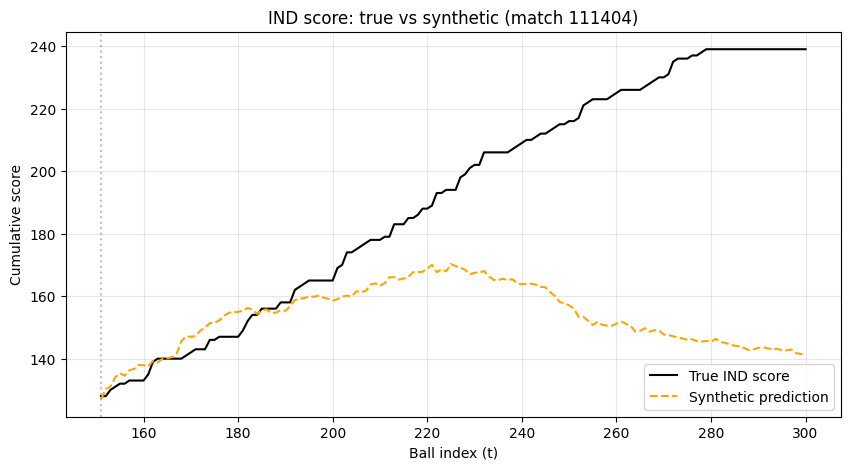

MSE: 2869.5262224190383


In [11]:
df = cricket[(cricket["Home"] == "SL") &
             (cricket["Away"] == "IND") &
             (cricket["MatchInn"] == 2)].copy()

df["StartDate"] = pd.to_datetime(df["StartDate"])
df = df.sort_values(["StartDate", "MatchNbr"]).reset_index(drop=True)

score_cols = [c for c in df.columns if "." in c]   # 300 bowls

print("Number of selected matches:", df["MatchNbr"].nunique())

target_match = 111404
row_target = df[df["MatchNbr"] == target_match].iloc[0]
y_target_full = row_target[score_cols].values.astype(float)  

T0 = 150 
y_target_obs = y_target_full[:T0]         
y_target_future = y_target_full[T0:]      

donor_df = df[df["MatchNbr"] != target_match].copy()
donor_matrix = donor_df[score_cols].values.astype(float)     
M = donor_matrix.shape[0]

print("Donor pool matches:", M)

X = donor_matrix[:, :T0].T     
y = y_target_obs               

X_const = sm.add_constant(X, has_constant="add")
model = sm.OLS(y, X_const).fit()
params = model.params          

c = params[0]
w = params[1:]                  

y_synth_full = c + donor_matrix.T @ w    

y_pred_future = y_synth_full[T0:]        

bowls_future = np.arange(T0+1, 300+1)    

plt.figure(figsize=(10,5))
plt.plot(bowls_future, y_target_future, label="True IND score", color="black")
plt.plot(bowls_future, y_pred_future, label="Synthetic prediction", color="orange", linestyle="--")
plt.axvline(T0+1, color="grey", linestyle=":", alpha=0.5)
plt.xlabel("Ball index (t)")
plt.ylabel("Cumulative score")
plt.title("IND score: true vs synthetic (match 111404)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

mse = np.mean((y_pred_future - y_target_future)**2)
print("MSE:", mse)